In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Open this notebook from the NutriCore repository or its notebooks directory.")

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
os.chdir(PROJECT_ROOT)

# Review Data Preprocessing

This notebook focuses on preparing the Food.com review dataset for use in the recipe recommendation system.

While the recipe dataset provides nutritional and recipe-level information, the review dataset captures user interactions in the form of ratings and textual feedback. These interactions can be used to measure recipe popularity and support the development of collaborative filtering recommendation models.

The objectives of this notebook are to:

* Understand the structure and quality of the review dataset.
* Ensure consistency between recipe and review data sources.
* Analyze user rating behavior.
* Investigate user and recipe activity patterns.
* Create popularity-based features for downstream recommendation tasks.
* Generate a cleaned review dataset for future recommendation models.

The processed outputs generated in this notebook will be used alongside the processed recipe dataset in subsequent stages of the project.


In [2]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt



## Loading Datasets

Two datasets are required for this stage of the project:

1. Processed recipe dataset generated in Notebook 1.
2. Raw review dataset.

Before analyzing reviews, both datasets are loaded so that review records can be aligned with the recipes retained during recipe preprocessing.

This ensures that all review information corresponds only to recipes available for recommendation.


In [3]:
# Load Datasets

recipes_df = pd.read_parquet(
    "data/processed/recipes_processed.parquet"
)

reviews_df = pd.read_parquet(
    "data/raw/reviews.parquet"
)

print("Recipes Shape :", recipes_df.shape)
print("Reviews Shape :", reviews_df.shape)

Recipes Shape : (302965, 16)
Reviews Shape : (1401982, 8)


## Dataset Consistency Check

The recipe dataset underwent extensive preprocessing in Notebook 1, including the removal of recipes with missing serving information and invalid nutritional values.

As a result, not every recipe present in the original Food.com dataset is available in the processed recipe dataset.

Since the recommendation engine will operate exclusively on the processed recipes, review records associated with removed recipes must also be excluded.

This step ensures consistency between the recipe and review datasets and prevents the generation of popularity statistics or recommendation signals for recipes that are no longer available.


In [4]:
# Identify Valid Recipe IDs

valid_recipe_ids = set(
    recipes_df["RecipeId"]
)

total_reviews_before = len(reviews_df)

reviews_df = reviews_df[
    reviews_df["RecipeId"].isin(
        valid_recipe_ids
    )
]

total_reviews_after = len(reviews_df)

removed_reviews = (
    total_reviews_before -
    total_reviews_after
)

print(f"Reviews Before Filtering : {total_reviews_before:,}")
print(f"Reviews After Filtering  : {total_reviews_after:,}")
print(f"Reviews Removed          : {removed_reviews:,}")

print(
    f"Percentage Removed       : "
    f"{100 * removed_reviews / total_reviews_before:.2f}%"
)

Reviews Before Filtering : 1,401,982
Reviews After Filtering  : 788,843
Reviews Removed          : 613,139
Percentage Removed       : 43.73%


### Dataset Alignment Findings

The review dataset originally contained **1,401,982** review records. After aligning the review data with the processed recipe dataset, **613,139** reviews were removed, representing approximately **43.73%** of all reviews.

This reduction was expected because a substantial number of recipes were removed during recipe preprocessing due to missing serving information, invalid nutritional values, and other quality-related issues.

Retaining reviews associated with removed recipes would introduce inconsistencies into the recommendation pipeline. Such reviews could contribute popularity signals, ratings, or collaborative filtering interactions for recipes that are no longer available for recommendation.

After filtering, the dataset contains **788,843** valid reviews linked exclusively to recipes present in the processed recipe dataset. This ensures consistency across all project datasets and establishes a reliable foundation for downstream recommendation models.


## Review Dataset Overview

Before performing data cleaning and feature engineering, it is important to understand the structure of the review dataset.

This section examines:

* Dataset dimensions
* Available features
* Data types
* Sample records

Understanding the dataset structure helps identify potential data quality issues and informs subsequent preprocessing decisions.


In [5]:
# Dataset Shape

print(f"Rows    : {reviews_df.shape[0]:,}")
print(f"Columns : {reviews_df.shape[1]}")

Rows    : 788,843
Columns : 8


In [6]:
# Column Names

reviews_df.columns.tolist()

['ReviewId',
 'RecipeId',
 'AuthorId',
 'AuthorName',
 'Rating',
 'Review',
 'DateSubmitted',
 'DateModified']

In [7]:
# Sample Records

reviews_df.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17 16:49:59+00:00,2001-10-17 16:49:59+00:00
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25 09:00:00+00:00,2000-02-25 09:00:00+00:00
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13 21:15:00+00:00,2000-03-13 21:15:00+00:00
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28 12:51:00+00:00,2000-03-28 12:51:00+00:00
5,17,5221,2046,Gay Gilmore ckpt,4,"love it, but without the bean sprouts.",2000-05-08 11:08:00+00:00,2000-05-08 11:08:00+00:00


In [8]:
# Dataset Information

reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 788843 entries, 1 to 1401981
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   ReviewId       788843 non-null  int32              
 1   RecipeId       788843 non-null  int32              
 2   AuthorId       788843 non-null  int32              
 3   AuthorName     788843 non-null  object             
 4   Rating         788843 non-null  int32              
 5   Review         788843 non-null  object             
 6   DateSubmitted  788843 non-null  datetime64[us, UTC]
 7   DateModified   788843 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](2), int32(4), object(2)
memory usage: 42.1+ MB


## Data Quality Assessment

The review dataset was examined for missing values across all features to identify any incomplete records that could affect downstream analysis or recommendation models.


In [9]:
reviews_df.isnull().sum()

ReviewId         0
RecipeId         0
AuthorId         0
AuthorName       0
Rating           0
Review           0
DateSubmitted    0
DateModified     0
dtype: int64

### Missing-Value Findings

No missing values were identified in the review dataset. Since all records contain complete information, no imputation or row removal is required.


### Duplicate Analysis

Duplicate records can distort popularity statistics and user interaction patterns. Therefore, the dataset is checked for duplicate entries before further analysis.


In [10]:
duplicate_rows = reviews_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows:,}")

print(
    f"Unique Review IDs: "
    f"{reviews_df['ReviewId'].nunique():,}"
)

Duplicate Rows: 0
Unique Review IDs: 788,843


### Duplicate-Record Findings

No duplicate records were identified in the filtered review dataset.

Additionally, the number of unique review identifiers matches the total number of reviews, confirming that each review represents a distinct user interaction.

Since no duplicate observations are present, no duplicate removal is required before proceeding with further analysis.


## Rating Analysis

Ratings represent the primary form of user feedback within the review dataset and play a critical role in recommendation systems.

Analyzing rating distributions helps identify:

* User rating behavior
* Potential rating bias
* Class imbalance
* Overall sentiment toward recipes

Understanding these patterns is important for both popularity-based recommendations and collaborative filtering models.


In [11]:
# Rating Distribution

rating_counts = (
    reviews_df["Rating"]
    .value_counts()
    .sort_index()
)

rating_counts

Rating
0     40037
1      8568
2      9772
3     29056
4    135782
5    565628
Name: count, dtype: int64

In [12]:
# Rating Distribution (%)

rating_percentages = round(
    reviews_df["Rating"]
    .value_counts(normalize=True)
    .sort_index() * 100,
    2
)

rating_percentages

Rating
0     5.08
1     1.09
2     1.24
3     3.68
4    17.21
5    71.70
Name: proportion, dtype: float64

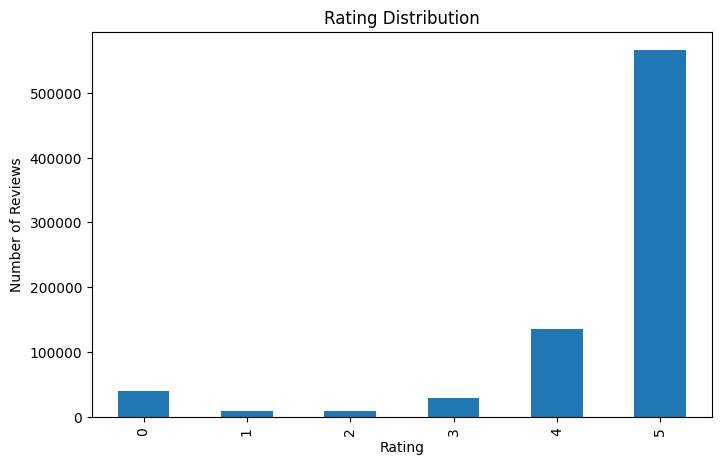

In [13]:
# Rating Distribution Visualization

plt.figure(figsize=(8,5))

reviews_df["Rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

### Rating Distribution Findings

The rating distribution is heavily skewed toward positive feedback. Approximately 88.91% of all reviews have ratings of 4 or 5, with 5-star ratings alone accounting for 71.7% of the dataset.

This pattern suggests a strong positive rating bias, which is common in online recipe platforms where users are more likely to review recipes they enjoyed.

The observed imbalance indicates that average rating alone may not be sufficient for measuring recipe quality. Therefore, future popularity metrics should consider both rating values and review frequency to provide a more reliable estimate of recipe popularity.




### Rating Summary Statistics

To further understand user rating behavior, descriptive statistics are computed for the rating feature.

These statistics provide a concise summary of the central tendency and variability of user ratings within the dataset.


In [14]:
### Rating Summary Statistics

reviews_df["Rating"].describe()

count    788843.000000
mean          4.419825
std           1.239753
min           0.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Rating, dtype: float64

### Rating Summary Findings

The summary statistics further reinforce the positive rating bias observed in the dataset.

The average rating is approximately **4.42**, while the median rating is **5**, indicating that highly positive reviews dominate user feedback. Furthermore, the first quartile (25th percentile) is **4**, meaning that at least 75% of all reviews have ratings of 4 or higher.

The relatively small spread between the median and the maximum possible rating suggests that user ratings are concentrated toward the upper end of the rating scale. This pattern is commonly observed in online recipe communities, where users are more likely to leave reviews after successfully preparing and enjoying a recipe.

Given this strong concentration of high ratings, average rating alone may not be sufficient for identifying the most reliable recipes. Therefore, future popularity metrics should incorporate both rating values and review counts to better distinguish consistently popular recipes from those with only a small number of reviews.


In [15]:
# Reviews per User

user_review_counts = (
    reviews_df
    .groupby("AuthorId")
    .size()
    .sort_values(ascending=False)
)

user_review_counts.describe()

count    170039.000000
mean          4.639189
std          40.499042
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        5172.000000
dtype: float64

### User Base Findings

The review dataset contains interactions from **170,039 unique users**, indicating a large and diverse user base.

User activity is highly skewed. The median number of reviews per user is **1**, while the 75th percentile is **2**, suggesting that most users contribute only a small number of reviews. In contrast, a small group of highly active users contributes a substantially larger number of reviews, with the most active user having submitted **5,172 reviews**.

This distribution is characteristic of many online communities, where participation is dominated by a relatively small number of highly engaged users.

The observed sparsity may present challenges for collaborative filtering models, as many users have limited interaction histories. However, the overall scale of the dataset and the presence of highly active users provide sufficient interaction data to support recommendation modeling in later stages of the project.


In [16]:
# Top 10 Most Active Users

top_users = (
    reviews_df
    .groupby(["AuthorId", "AuthorName"])
    .size()
    .reset_index(name="ReviewCount")
    .sort_values(
        "ReviewCount",
        ascending=False
    )
)

top_users.head(10)

,AuthorId,AuthorName,ReviewCount
38216,424680,Sydney Mike,5172
3277,37449,Sharon123,4015
35828,383346,Boomette,2969
16736,169430,Annacia,2928
12790,128473,Baby Kato,2779
19749,199848,Parsley,2398
29181,305531,lazyme,2385
13165,133174,PaulaG,2342
22314,226863,breezermom,2243
179,4470,Bergy,2191


### User Activity Findings

The distribution of user activity is highly imbalanced. While most users contribute only a small number of reviews, a small group of highly active users contributes thousands of reviews.

The most active reviewer in the dataset has submitted **5,172 reviews**, while several other users have contributed more than **2,000 reviews** each.

This long-tail participation pattern is common in online communities, where a relatively small number of highly engaged users generate a substantial portion of the available interaction data.

Such users can provide valuable signals for collaborative filtering models because their extensive interaction histories help establish stronger relationships between recipes and user preferences.


## Engagement Analysis

To better understand participation patterns, the distribution of review counts per user is visualized.

Since a small number of highly active users contribute a disproportionately large number of reviews, the distribution is expected to be heavily right-skewed.


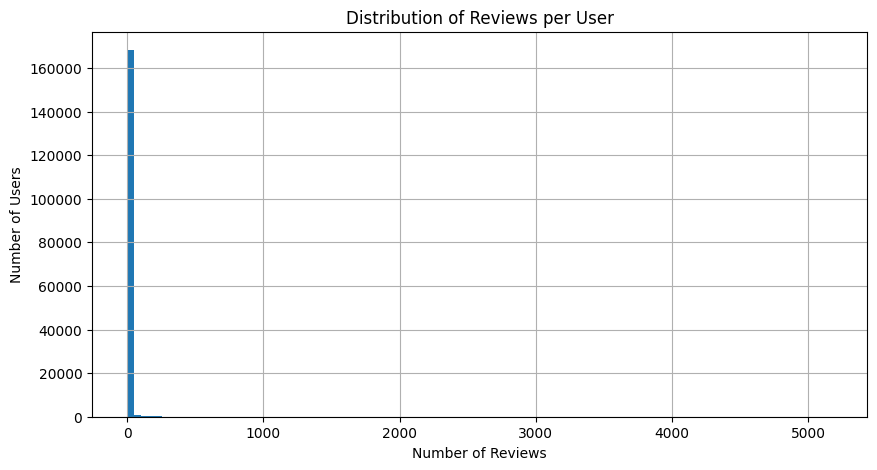

In [17]:
## Engagement Analysis

plt.figure(figsize=(10,5))

user_review_counts.hist(
    bins=100
)

plt.title("Distribution of Reviews per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")

plt.show()

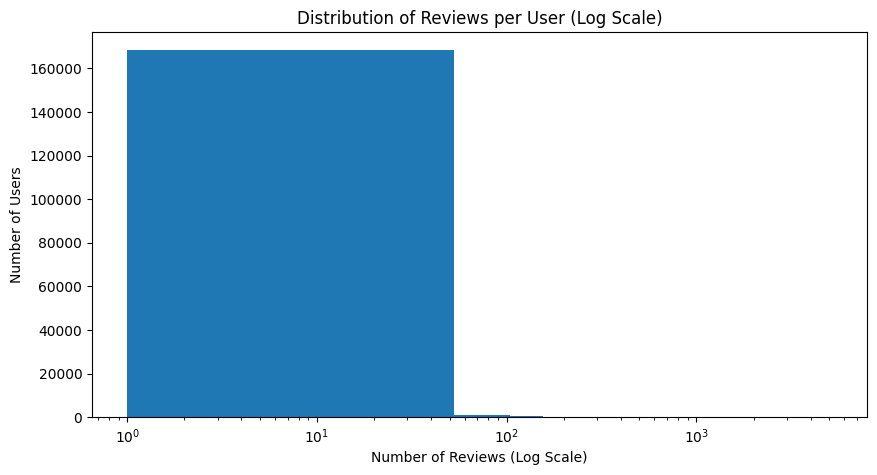

In [18]:
# User Activity Distribution (Log Scale)

plt.figure(figsize=(10,5))

plt.hist(
    user_review_counts,
    bins=100
)

plt.xscale("log")

plt.title("Distribution of Reviews per User (Log Scale)")
plt.xlabel("Number of Reviews (Log Scale)")
plt.ylabel("Number of Users")

plt.show()

### User Activity Distribution Findings

The user activity distribution is highly right-skewed, with the majority of users contributing only a small number of reviews.

The standard histogram shows that a few highly active users contribute thousands of reviews, causing most users to be compressed near the origin. The logarithmic visualization provides a clearer view of the distribution and confirms the presence of a long-tail participation pattern.

Most users interact with only one or two recipes, while a relatively small group of highly engaged users contributes a substantial number of reviews. Such interaction patterns are commonly observed in recommendation systems and online communities.

The observed sparsity suggests that many users provide limited preference information. Consequently, collaborative filtering models may benefit from applying minimum interaction thresholds when constructing user-item matrices in later stages of the project.


### Recipe Activity Analysis

Recipe activity reflects the level of user engagement associated with individual recipes.

Analyzing review frequency at the recipe level helps identify highly popular recipes, understand interaction patterns across the recipe collection, and evaluate the reliability of recipe ratings.

These insights are particularly important for constructing popularity-based recommendation features that will be incorporated into the final recommendation system.


In [19]:
# Reviews per Recipe

recipe_review_counts = (
    reviews_df
    .groupby("RecipeId")
    .size()
)

recipe_review_counts.describe()

count    155842.000000
mean          5.061813
std          20.322298
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        2892.000000
dtype: float64

### Recipe Coverage Findings

The filtered review dataset contains reviews for **155,842 unique recipes**, representing the subset of recipes that remain after alignment with the processed recipe dataset.

Recipe activity follows a long-tail distribution. While the median recipe receives only **2 reviews**, a small number of highly popular recipes accumulate substantially more user feedback, with the most reviewed recipe receiving **2,892 reviews**.

The average recipe receives approximately **5 reviews**, indicating that user engagement is unevenly distributed across the recipe collection. Most recipes receive relatively few reviews, whereas a small subset attracts significant community attention.

These findings suggest that review frequency can serve as an important indicator of recipe popularity. However, because review counts vary considerably across recipes, popularity estimation should incorporate both rating quality and review volume to avoid favoring recipes with only a small number of highly positive reviews.


In [20]:
# Top 10 Most Reviewed Recipes

top_recipes = (
    reviews_df
    .groupby("RecipeId")
    .size()
    .sort_values(ascending=False)
)

top_recipes.head(10)

RecipeId
45809    2892
2886     2182
27208    1614
89204    1584
39087    1491
67256    1359
32204    1228
68955     910
82102     862
25885     856
dtype: int64

In [21]:
# Most Reviewed Recipes

top_recipes_df = (
    reviews_df
    .groupby("RecipeId")
    .size()
    .reset_index(name="ReviewCount")
    .sort_values(
        "ReviewCount",
        ascending=False
    )
)

top_recipes_df = top_recipes_df.merge(
    recipes_df[
        ["RecipeId", "Name"]
    ],
    on="RecipeId",
    how="left"
)

top_recipes_df.head(10)

,RecipeId,ReviewCount,Name
0,45809,2892,Bourbon Chicken
1,2886,2182,Best Banana Bread
2,27208,1614,To Die for Crock Pot Roast
3,89204,1584,Crock-Pot Chicken With Black Beans &amp; Cream...
4,39087,1491,Creamy Cajun Chicken Pasta
5,67256,1359,Best Ever Banana Cake With Cream Cheese Frosting
6,32204,1228,&quot;Whatever Floats Your Boat&quot; Brownies!
7,68955,910,Japanese Mum's Chicken
8,82102,862,Kittencal's Moist Cheddar-Garlic Oven Fried Ch...
9,25885,856,Banana Banana Bread


### Top Recipe Findings

The most reviewed recipes consist primarily of well-known and broadly appealing dishes such as chicken-based meals, baked goods, cookies, cakes, and brownies.

The presence of thousands of reviews for several recipes indicates strong user engagement and suggests that review count can serve as a meaningful measure of recipe popularity.

Furthermore, the identified recipes appear reasonable and consistent with expectations for a community-driven recipe platform, providing additional validation that the recipe-review alignment process was successful.


## Recipe Popularity Features

The review dataset provides valuable information regarding recipe popularity and user satisfaction.

To support popularity-based recommendation strategies, recipe-level popularity features are generated by aggregating review information across all reviews associated with each recipe.

The following features are created:

* AverageRating: Mean rating received by a recipe.
* ReviewCount: Total number of reviews associated with a recipe.
* WeightedRating: Popularity-adjusted rating that considers both rating quality and review volume.

These features will later be merged with the processed recipe dataset and incorporated into the final recommendation system.


In [22]:
# Recipe Popularity Features

recipe_popularity_df = (
    reviews_df
    .groupby("RecipeId")
    .agg(
        AverageRating=("Rating", "mean"),
        ReviewCount=("Rating", "count")
    )
    .reset_index()
)

recipe_popularity_df.head()

,RecipeId,AverageRating,ReviewCount
0,38,4.250000,4
1,39,3.000000,1
2,40,4.333333,9
3,41,4.500000,2
4,42,2.666667,9


In [23]:
recipe_popularity_df.describe()

,RecipeId,AverageRating,ReviewCount
count,155842.000000,155842.000000,155842.000000
mean,224410.207556,4.357533,5.061813
std,142646.308049,0.962420,20.322298
min,38.000000,0.000000,1.000000
25%,101527.500000,4.000000,1.000000
50%,211516.000000,4.666667,2.000000
75%,337703.000000,5.000000,4.000000
max,541298.000000,5.000000,2892.000000


### Weighted Rating Calculation

Average ratings can be misleading when based on only a small number of reviews. For example, a recipe with a single 5-star review may appear superior to a recipe with hundreds of highly positive reviews.

To address this issue, a Bayesian weighted rating is calculated. This approach combines the recipe's average rating with the overall average rating of the dataset, while accounting for the number of reviews associated with each recipe.

As the number of reviews increases, the weighted rating becomes increasingly influenced by the recipe's own rating. Conversely, recipes with very few reviews are pulled toward the global average rating.

This technique provides a more reliable estimate of recipe quality and is commonly used in ranking systems such as movie and product recommendation platforms.


In [24]:
# Bayesian Weighted Rating

C = recipe_popularity_df["AverageRating"].mean()

m = recipe_popularity_df["ReviewCount"].quantile(0.75)

print(f"Global Average Rating (C): {C:.3f}")
print(f"Minimum Review Threshold (m): {m:.0f}")

Global Average Rating (C): 4.358
Minimum Review Threshold (m): 4




For this dataset:

* **C = 4.358** represents the average rating across all reviewed recipes.
* **m = 4** represents the review-count threshold derived from the 75th percentile of the review count distribution.

Consequently, recipes with fewer than four reviews are adjusted more strongly toward the global average rating, while recipes with larger numbers of reviews retain ratings closer to their observed averages.


### Bayesian Weighted Rating Formula

Average ratings alone can be misleading when based on a small number of reviews. To obtain a more reliable measure of recipe quality, a Bayesian weighted rating is computed for each recipe.

$$
WR=
\left(\frac{v}{v+m}\right)R
+
\left(\frac{m}{v+m}\right)C
$$

Where:

- **WR** = Weighted Rating
- **R** = Average rating of the recipe
- **v** = Number of reviews for the recipe
- **C** = Global average rating across all recipes
- **m** = Minimum review threshold

This formula balances a recipe's own rating with the overall average rating of the dataset.

* Recipes with **many reviews** are influenced primarily by their own ratings.
* Recipes with **few reviews** are pulled closer to the global average rating.
* The approach reduces the impact of small sample sizes and produces more reliable popularity rankings.

The review threshold (**m**) is chosen as the 75th percentile of the review count distribution, ensuring that recipes require a reasonable amount of user feedback before their individual ratings are fully trusted.


In [25]:
recipe_popularity_df["WeightedRating"] = (
    (recipe_popularity_df["ReviewCount"] /
     (recipe_popularity_df["ReviewCount"] + m))
    * recipe_popularity_df["AverageRating"]
    +
    (m /
     (recipe_popularity_df["ReviewCount"] + m))
    * C
)

### Example

Consider a recipe with:

- Average Rating (R) = 5.0
- Review Count (v) = 1
- Global Average Rating (C) = 4.358
- Minimum Review Threshold (m) = 4

Substituting these values into the formula:

$$
WR=
\frac{1}{1+4}(5.0)
+
\frac{4}{1+4}(4.358)
$$

$$
WR \approx 4.49
$$

Although the recipe received a perfect rating, the weighted score is pulled toward the global average because it is based on only a single review.

In [26]:
recipe_popularity_df.sort_values(
    "WeightedRating",
    ascending=False
).head(10)

,RecipeId,AverageRating,ReviewCount,WeightedRating
150625,486261,4.990783,217,4.979322
9623,24768,5.000000,37,4.937320
62742,166669,5.000000,36,4.935753
73746,199171,5.000000,31,4.926575
10032,25735,4.976190,42,4.922394
17851,45107,5.000000,28,4.919692
6877,18514,5.000000,28,4.919692
151823,495202,5.000000,28,4.919692
88969,244861,5.000000,27,4.917101
31856,84651,5.000000,27,4.917101


In [27]:
top_popular = (
    recipe_popularity_df
    .sort_values(
        "WeightedRating",
        ascending=False
    )
    .head(10)
)

top_popular = top_popular.merge(
    recipes_df[
        ["RecipeId", "Name"]
    ],
    on="RecipeId",
    how="left"
)

top_popular

,RecipeId,AverageRating,ReviewCount,WeightedRating,Name
0,486261,4.990783,217,4.979322,Mexican Stack-Up #RSC
1,24768,5.000000,37,4.937320,Berry Cream Cheese Coffee Cake
2,166669,5.000000,36,4.935753,Kittencal's Caesar Tortellini Salad
3,199171,5.000000,31,4.926575,Broiled Cinnamon Toast
4,25735,4.976190,42,4.922394,Autumn Chicken Salad
5,45107,5.000000,28,4.919692,Strawberry Cheese Ring
6,18514,5.000000,28,4.919692,Eclair Cake
7,495202,5.000000,28,4.919692,Crunchy Valley Chicken #RSC
8,244861,5.000000,27,4.917101,Kittencal's Parmesan Orzo
9,84651,5.000000,27,4.917101,Onion Roasted Potatoes


### Weighted Rating Findings

The Bayesian weighted rating successfully balances rating quality and review volume when ranking recipes.

The highest-ranked recipes combine consistently high user ratings with a meaningful number of reviews, indicating strong and reliable user satisfaction. Unlike simple average ratings, the weighted rating reduces the influence of recipes that achieve perfect scores from only a small number of reviews.

The resulting rankings provide a robust measure of recipe popularity and will serve as an important recommendation signal in the final hybrid recommendation system.


### Popularity Score Normalization

The Bayesian weighted rating provides a reliable estimate of recipe popularity by combining rating quality and review volume. However, the weighted rating is expressed on a **0–5 scale**, whereas the hybrid recommendation model combines multiple recommendation components on a **0–1 scale**.

To ensure compatibility with the hybrid recommendation framework, the weighted rating is converted to a normalized popularity score using a simple scale transformation:

$$
PopularityScore=\frac{WeightedRating}{5}
$$

Unlike dataset-dependent normalization techniques such as Min-Max scaling, this transformation preserves the original interpretation of the Bayesian weighted rating while mapping it directly to the 0–1 range.

Because the Bayesian weighted rating is already statistically corrected and bounded between 0 and 5, dividing by the maximum possible rating provides a consistent and interpretable popularity score without artificially exaggerating small differences between recipes.


In [28]:
# Normalize Popularity Score

recipe_popularity_df["PopularityScore"] = (
    recipe_popularity_df["WeightedRating"] / 5
).round(4)

recipe_popularity_df.head()

,RecipeId,AverageRating,ReviewCount,WeightedRating,PopularityScore
0,38,4.250000,4,4.303766,0.8608
1,39,3.000000,1,4.086026,0.8172
2,40,4.333333,9,4.340779,0.8682
3,41,4.500000,2,4.405022,0.8810
4,42,2.666667,9,3.186933,0.6374


## Final Data Preparation

Before exporting the processed datasets, numerical popularity features are finalized for downstream use.

The following preprocessing steps are performed:

* AverageRating is rounded to three decimal places.
* WeightedRating is rounded to three decimal places.
* PopularityScore is generated by converting the Bayesian weighted rating from the 0–5 scale to a normalized 0–1 scale.

These transformations improve readability while preserving the statistical properties of the popularity features used by the recommendation system.


In [29]:
# Round Popularity Features

recipe_popularity_df["AverageRating"] = (
    recipe_popularity_df["AverageRating"]
    .round(3)
)

recipe_popularity_df["WeightedRating"] = (
    recipe_popularity_df["WeightedRating"]
    .round(3)
)

recipe_popularity_df.head()

,RecipeId,AverageRating,ReviewCount,WeightedRating,PopularityScore
0,38,4.250,4,4.304,0.8608
1,39,3.000,1,4.086,0.8172
2,40,4.333,9,4.341,0.8682
3,41,4.500,2,4.405,0.8810
4,42,2.667,9,3.187,0.6374


## Export Processed Datasets

After preprocessing and feature engineering, the cleaned review dataset and recipe popularity features are exported for use in subsequent stages of the project.

The datasets are stored as Parquet files:

### Parquet Files

- reviews_processed.parquet
- recipe_popularity.parquet

Parquet files provide efficient storage and faster loading times for large datasets.

These datasets will be integrated with the processed recipe dataset during recommendation model development.

The reviews dataset retains review identifiers, user information, ratings, review text, and temporal metadata. Preserving these attributes supports future development of collaborative filtering, user-profile features, review analysis, and application-level functionality.

In [30]:
## Export Processed Datasets

# Reviews Dataset
reviews_df.to_parquet(
    "data/processed/reviews_processed.parquet",
    index=False
)

# Popularity Dataset
recipe_popularity_df.to_parquet(
    "data/processed/recipe_popularity.parquet",
    index=False
)

print("All files exported successfully.")

All files exported successfully.


In [31]:
# Verify Exported Files

print("Reviews Dataset Shape:")
print(reviews_df.shape)

print("\nPopularity Dataset Shape:")
print(recipe_popularity_df.shape)

Reviews Dataset Shape:
(788843, 8)

Popularity Dataset Shape:
(155842, 5)


## Summary

In this notebook, the Food.com review dataset was prepared and transformed into a set of features suitable for use in the recipe recommendation system.

## Key Preprocessing Steps

* Loaded the processed recipe dataset and the original review dataset.
* Aligned review records with recipes retained after recipe preprocessing.
* Removed reviews associated with excluded recipes.
* Validated dataset completeness by checking missing values, duplicate records, and review uniqueness.
* Analyzed rating distributions to understand user feedback patterns and identify rating bias.
* Examined user activity and recipe activity distributions to assess interaction sparsity and engagement.
* Identified the most active users and the most frequently reviewed recipes.
* Engineered recipe-level popularity features, including average rating and review count.
* Computed Bayesian weighted ratings to generate statistically reliable popularity estimates.
* Normalized the Bayesian weighted ratings to a 0–1 popularity score for integration into the hybrid recommendation model.
* Prepared and exported the final processed datasets for downstream recommendation tasks.

## Generated Features

The recipe popularity dataset contains the following features:

* RecipeId
* AverageRating
* ReviewCount
* WeightedRating
* PopularityScore

These features provide a robust representation of recipe popularity by combining rating quality with review volume. The Bayesian weighted rating serves as an interpretable popularity metric, while the normalized popularity score is intended for direct use within the hybrid recommendation system.

## Exported Datasets

### Reviews Dataset

* reviews_processed.parquet
### Recipe Popularity Dataset

* recipe_popularity.parquet

